Setup

In [42]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

import Simulation as S

In [67]:
image_folder = "C:\\Users\\rytoa\\Desktop\\School Stuff\\Research\\Delay Line\\DelayLine-main\\Inverse Simulation\\Stage Movement Photos/"

image_path = image_folder + "06-17-L6.jpg"
dark_path  = image_folder + "06-17-D6.jpg"

Display Image Normally

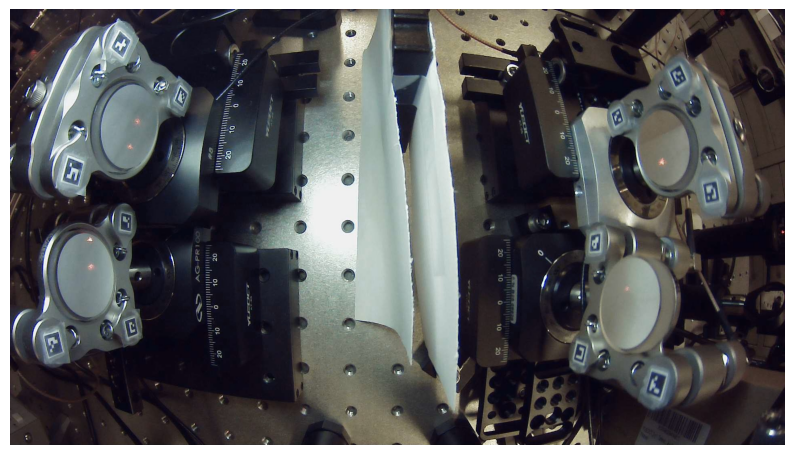

In [68]:
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise FileNotFoundError("Could not read image path")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,7))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

Find ArUco Centers

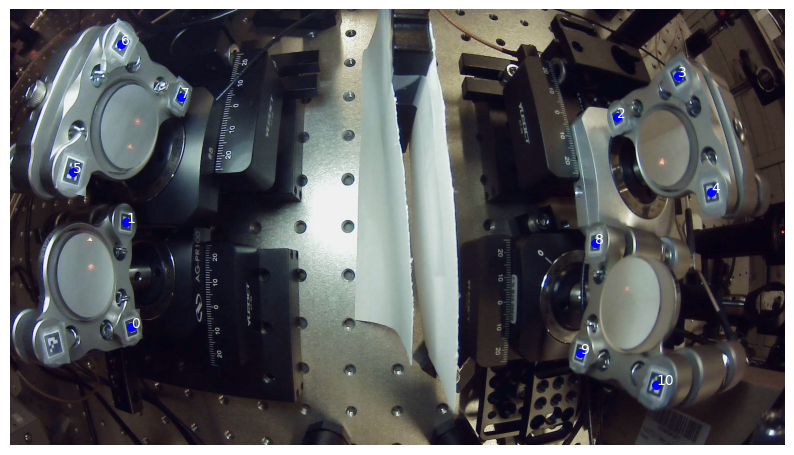

In [69]:
# Get aruco center points
aruco_centers = S.camera_arucos(image_path)

# Plot center points on original image
plt.figure(figsize=(10,7))
plt.imshow(img_rgb)
plt.axis("off")

count = 0
for x, y in aruco_centers:
    plt.scatter(x, y, color='blue', s=30)
    plt.text(x, y, str(count), color='white')
    count += 1
plt.show()

Establish Mirror Parameters

In [65]:
# Guess mirror parameters
M1 = [181.98742914, 109.72234719,   93.67520394]
M2 = [17.79979716,  74.44917476,    92.91711119]
M3 = [168.76718674, 69.36197468,    80.84612172]
M4 = [40.19341535,  117.66002991,   80.29060775]


# Optimize to find actual mirror parameters
#opt_out = S.optimize_inverse(M1, M2, M3, M4, image_path, dark_path, qc1_disp=0, qc2_disp=0)
#x = opt_out.x

# Save optimized parameters
#M1 = [x[0], x[1], x[2]]
#M2 = [x[3], x[4], x[5]]
#M3 = [x[6], x[7], x[8]]
#M4 = [x[9], x[10], x[11]]

Solve Simulation

NOT CLIPPED, room to spare: 2.9802084028877758 mm
Laser Path: [(0, 100), (np.float64(182.6119200842803), np.float64(100.0)), (np.float64(17.58259239495615), np.float64(78.71166618197637)), (np.float64(169.62530377434248), np.float64(74.68730731023176)), (np.float64(39.5563243619809), np.float64(113.93656937080249)), (np.float64(182.13697461090143), np.float64(107.3941581231895)), (np.float64(17.596057888253227), np.float64(78.44741530488344)), (np.float64(168.4700127810365), np.float64(67.51776215747822)), (np.float64(-801.1277495807444), np.float64(312.2220310679884))]
Total Laser Length: 1615.025768567862 mm
Total Number of Reflection (N_R) = 7


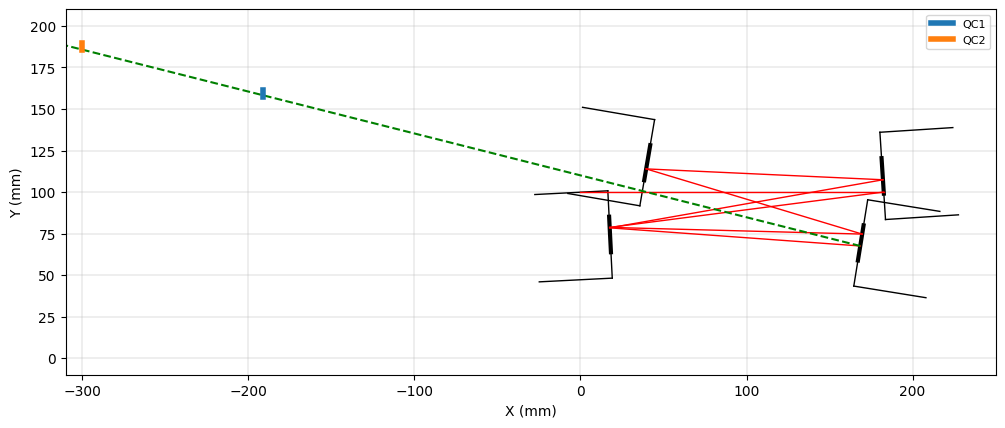

In [66]:
S.simulation(M1[0], M1[1],
             M2[0], M2[1],
             M3[0], M3[1],
             M4[0], M4[1],
             M1[2], M2[2], M3[2], M4[2])

Determine Reflection Points

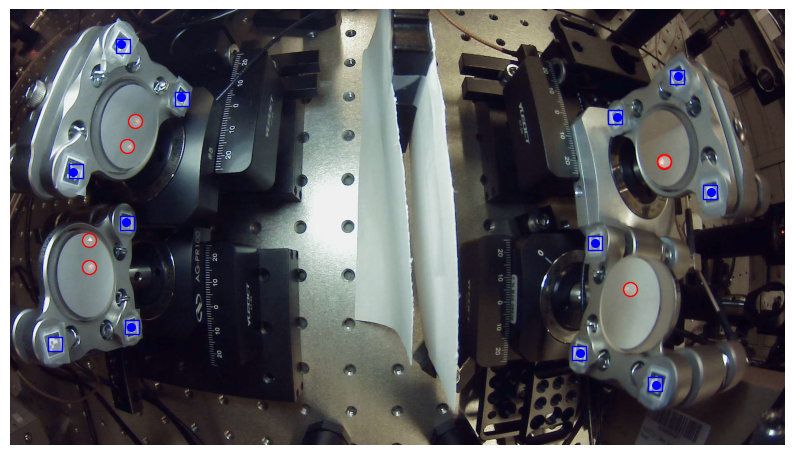

In [84]:
# Set up image
plt.figure(figsize=(10,7))
plt.imshow(img_rgb)
plt.axis("off")

# Get reflection points
reflections = S.simulation_reflec(M1[0], M1[1],
                                  M2[0], M2[1],
                                  M3[0], M3[1],
                                  M4[0], M4[1],
                                  M1[2], M2[2], M3[2], M4[2])

# Add reflection points to image
for point in reflections:
    # Get simulation point from result
    sim_r_pt = point['pt']

    # Convert simulation point to pixel coordinate
    px_r_pt = S.sim_to_px_reflec(sim_r_pt[0], sim_r_pt[1])

    # Add point to image
    plt.scatter(px_r_pt[0], px_r_pt[1], facecolor=(1, 1, 1, .2), edgecolor='red', marker='o', s=100)

# Add ArUco points to image
for mirror in [M1, M2, M3, M4]:
    sim_a_pt = S.sim_to_px(mirror[0], mirror[1], mirror[2])

    for a_pt in sim_a_pt:
        plt.scatter(a_pt[0], a_pt[1], facecolor=(1, 1, 1, .4), edgecolor='blue', marker='s', s=100)

# Add detected aruco centers to image
for x, y in aruco_centers:
    plt.scatter(x, y, color='blue', s=30)
    count += 1

plt.show()

